In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [6]:
#Importing the dataset
df = pd.read_csv('train.csv')

In [7]:
#Shape
df.shape

(891, 12)

In [8]:
#previewing the data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
#listing down the columns
df.columns.values

array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)

## Categorial Columns

##Servived
##PClass
##Sex
##SibSP
##Parch
##Embarked

## Numerical Columns

##Age
##Fare
##Passengerid


## Mixed Columns

##Name
##Ticket
##Cabin

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
# Few conclusion

#1.Missing values in age, cabin and embarked columns
#2.More than 70 percent values are missing in cabin columns, will have to drop
#3.Few columns have inappropriate data types

In [13]:
#Dropping cabin column
df.drop(columns=['Cabin'],inplace=True)

In [14]:
#Inputing missing values for age
#Strategy - mean 

df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\Rakshitha K V\AppData\Local\Temp\ipykernel_28992\2555049994.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [15]:
#Imputing missing values for embarked

#finding the most appeared value in embarked column

df['Embarked'].value_counts()

#S it is

df['Embarked'].fillna('S',inplace=True)

C:\Users\Rakshitha K V\AppData\Local\Temp\ipykernel_28992\2669993785.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna('S',inplace=True)


In [16]:
#Want to check one more thing..
#should i change the SibSp and parch to categories
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [17]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

## Changing data type for the following cols

In [18]:
df['Survived']=df['Survived'].astype('category')
df['Pclass']=df['Pclass'].astype('category')
df['Sex']=df['Sex'].astype('category')
df['Age']=df['Age'].astype('int')
df['Embarked']=df['Embarked'].astype('category')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    int64   
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(4), float64(1), int64(4), object(2)
memory usage: 52.8+ KB


In [20]:
#Five point summary
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.544332,0.523008,0.381594,32.204208
std,257.353842,13.013778,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,29.000000,0.000000,0.000000,14.454200
75%,668.500000,35.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


Out of 891 62 people died in the accident


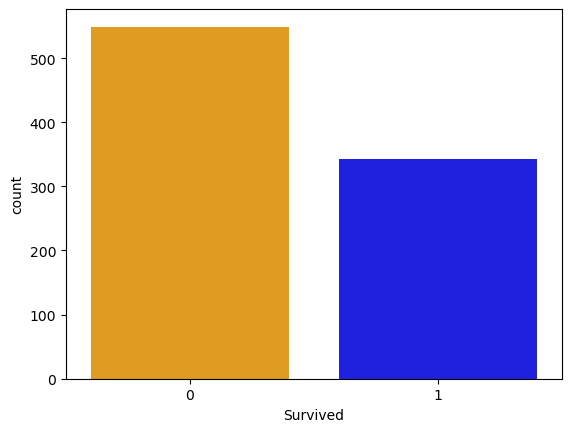

In [21]:
# Univariate Analysis

# Let's start with the Survived col

sns.countplot(
    x=df['Survived'],
    hue=df['Survived'],
    palette=['orange', 'blue'],
    legend=False
)

death_percent = round((df['Survived'].value_counts().values[0] / 891) * 100)

print("Out of 891 {} people died in the accident".format(death_percent))

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: count, dtype: float64


<Axes: xlabel='Pclass', ylabel='count'>

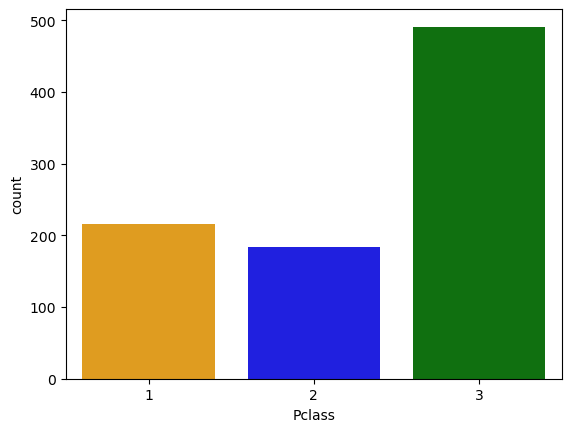

In [22]:
#Pclass column
print((df['Pclass']).value_counts()/891*100)

sns.countplot(
    x=df['Pclass'],
    hue=df['Pclass'],
    palette=['orange', 'blue', 'green'],
    legend=False
)

#Conclusion : Pclass was the most crowded class

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64


<Axes: xlabel='Sex', ylabel='count'>

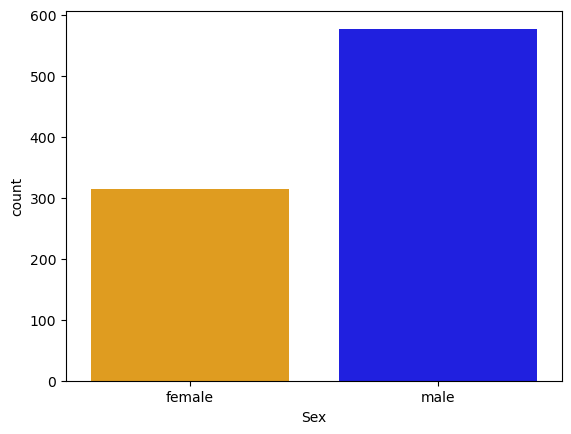

In [23]:
print((df['Sex'].value_counts() / 891) * 100)

sns.countplot(
    x=df['Sex'],
    hue=df['Sex'],
    palette=['orange', 'blue'],
    legend=False
)

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


<Axes: xlabel='SibSp', ylabel='count'>

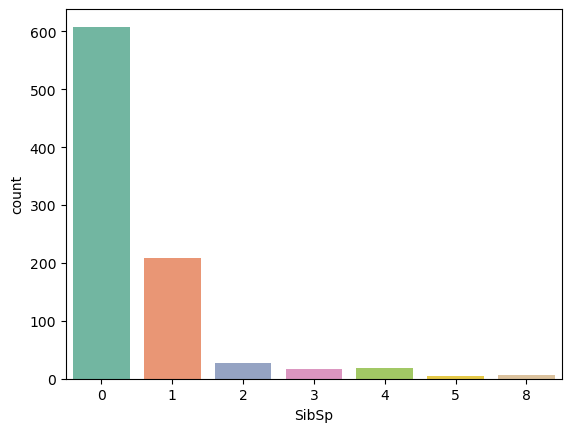

In [24]:
print(df['SibSp'].value_counts())

sns.countplot(
    x=df['SibSp'],
    hue=df['SibSp'],
    palette='Set2',
    legend=False
)

Parch
0    76.094276
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: count, dtype: float64


<Axes: xlabel='Parch', ylabel='count'>

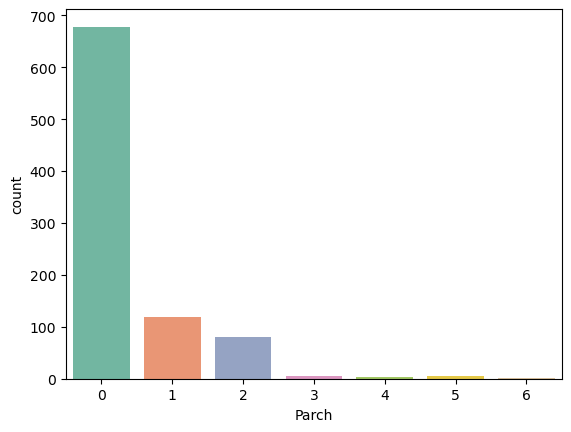

In [25]:
print((df['Parch'].value_counts()/891)*100)
sns.countplot(
    x=df['Parch'],
    hue=df['Parch'],
    palette='Set2',
    legend=False
)

Embarked
S    72.502806
C    18.855219
Q     8.641975
Name: count, dtype: float64


<Axes: xlabel='Embarked', ylabel='count'>

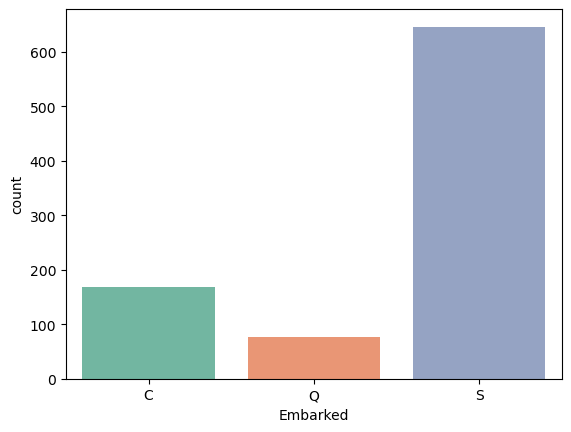

In [26]:
print((df['Embarked'].value_counts()/891)*100)
sns.countplot(
    x=df['Embarked'],
    hue=df['Embarked'],
    palette='Set2',
    legend=False
)

0.45956263424701577
0.9865867453652877


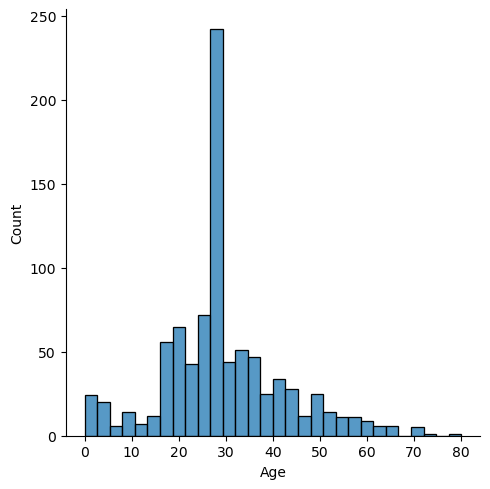

In [28]:
#Age column
sns.displot(df['Age'])
print(df['Age'].skew())
print(df['Age'].kurt())

<Axes: ylabel='Age'>

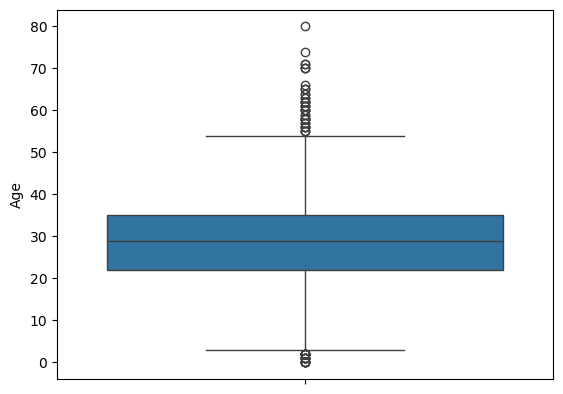

In [29]:
sns.boxplot(df['Age'])